In [430]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm  
from statsmodels.formula.api import logit 
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, roc_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import re

In [431]:
# Load the data and replace the path
df = pd.read_csv("/Users/helen/BASc/BASc0003/Economic indicators-final.csv")
X = df.drop(['Outcome', 'DATE'], axis=1)  
y = df['Outcome']  

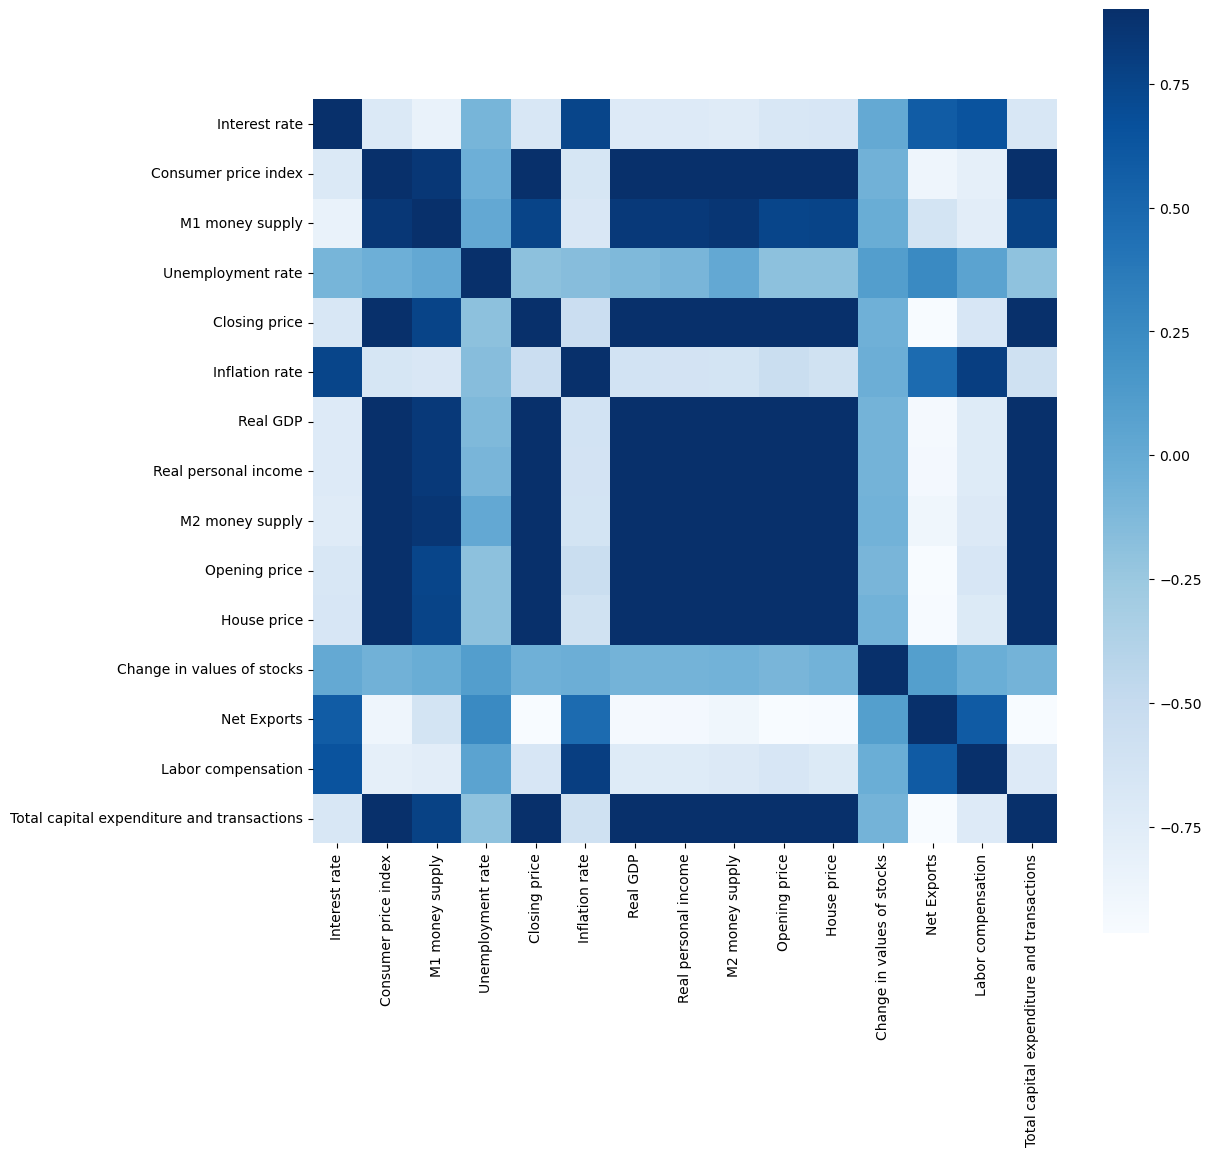

In [432]:
# Plot the correlation coefficients
def draw_corr_picture(X):   
    corrmat = X.corr()
    plt.subplots(figsize=(12,12))
    sns.heatmap(corrmat,vmax=0.9,square=True,cmap='Blues')
    plt.show()

draw_corr_picture(X)

In [433]:
# Output correlation matrix
corrmat = X.corr()
corrmat

,Interest rate,Consumer price index,M1 money supply,Unemployment rate,Closing price,Inflation rate,Real GDP,Real personal income,M2 money supply,Opening price,House price,Change in values of stocks,Net Exports,Labor compensation,Total capital expenditure and transactions
Interest rate,1.000000,-0.701863,-0.826674,-0.089446,-0.672228,0.748744,-0.717672,-0.720057,-0.737706,-0.671981,-0.660869,0.006456,0.586163,0.648666,-0.666896
Consumer price index,-0.701863,1.000000,0.848271,-0.044303,0.941897,-0.655855,0.984799,0.986061,0.978544,0.941873,0.968442,-0.059501,-0.876428,-0.792705,0.967959
M1 money supply,-0.826674,0.848271,1.000000,0.013010,0.755658,-0.673701,0.829228,0.831057,0.851560,0.752303,0.757095,-0.019343,-0.629431,-0.762949,0.775929
Unemployment rate,-0.089446,-0.044303,0.013010,1.000000,-0.188791,-0.159492,-0.122835,-0.096979,0.017416,-0.192753,-0.186800,0.098931,0.255062,0.061392,-0.197395
Closing price,-0.672228,0.941897,0.755658,-0.188791,1.000000,-0.547428,0.975476,0.973316,0.945546,0.998087,0.977197,-0.049045,-0.963100,-0.664491,0.986471
Inflation rate,0.748744,-0.655855,-0.673701,-0.159492,-0.547428,1.000000,-0.614472,-0.619073,-0.625996,-0.541209,-0.593638,-0.038892,0.475289,0.797985,-0.585751
Real GDP,-0.717672,0.984799,0.829228,-0.122835,0.975476,-0.614472,1.000000,0.999140,0.985418,0.975577,0.988630,-0.070792,-0.931653,-0.728076,0.991040
Real personal income,-0.720057,0.986061,0.831057,-0.096979,0.973316,-0.619073,0.999140,1.000000,0.989786,0.973541,0.985537,-0.070417,-0.927052,-0.726759,0.988087
M2 money supply,-0.737706,0.978544,0.851560,0.017416,0.945546,-0.625996,0.985418,0.989786,1.000000,0.945364,0.956447,-0.062287,-0.890276,-0.708175,0.960636
Opening price,-0.671981,0.941873,0.752303,-0.192753,0.998087,-0.541209,0.975577,0.973541,0.945364,1.000000,0.977105,-0.094925,-0.965032,-0.661760,0.986712


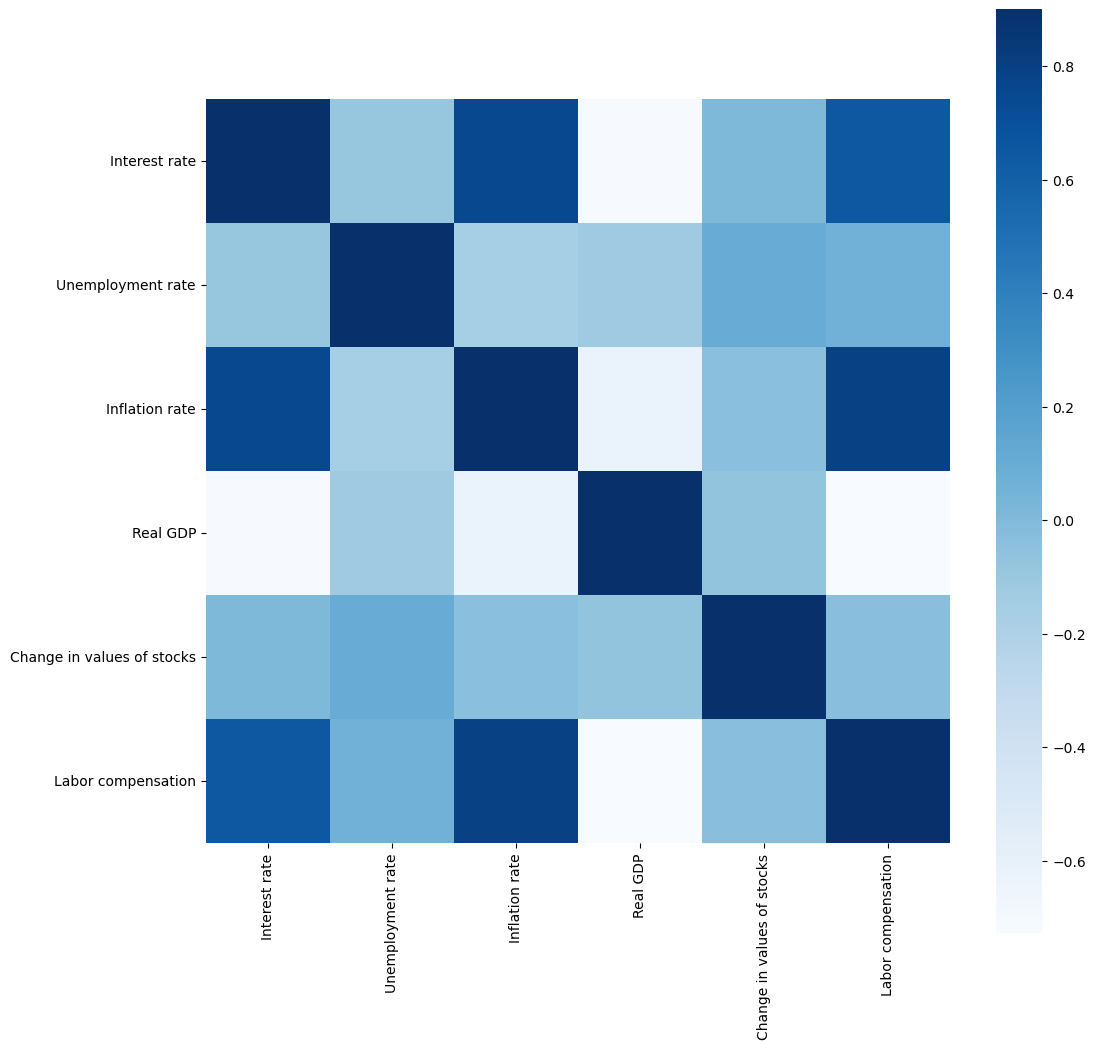

In [434]:

X_res = X.drop(['M1 money supply','House price', 'Net Exports','Real personal income','Closing price','Consumer price index', 
                'M2 money supply', 'Opening price', 'Total capital expenditure and transactions'], axis=1)
draw_corr_picture(X_res)

In [435]:
Res_corrmat = X_res.corr()
Res_corrmat

,Interest rate,Unemployment rate,Inflation rate,Real GDP,Change in values of stocks,Labor compensation
Interest rate,1.000000,-0.089446,0.748744,-0.717672,0.006456,0.648666
Unemployment rate,-0.089446,1.000000,-0.159492,-0.122835,0.098931,0.061392
Inflation rate,0.748744,-0.159492,1.000000,-0.614472,-0.038892,0.797985
Real GDP,-0.717672,-0.122835,-0.614472,1.000000,-0.070792,-0.728076
Change in values of stocks,0.006456,0.098931,-0.038892,-0.070792,1.000000,-0.029500
Labor compensation,0.648666,0.061392,0.797985,-0.728076,-0.029500,1.000000


In [ ]:

X.describe()

,Interest rate,Consumer price index,M1 money supply,Unemployment rate,Closing price,Inflation rate,Real GDP,Real personal income,M2 money supply,Opening price,House price,Change in values of stocks,Net Exports,Labor compensation,Total capital expenditure and transactions
count,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,2.760000e+02
mean,6.599529,135.093116,618.326087,7.000725,523.273188,4.965308,10896.461076,8970.582971,3956.058696,521.963768,193.096957,0.640652,-231.449130,4.624092,2.100954e+06
std,4.416135,55.745640,114.669032,1.623509,486.607793,3.233423,3970.698031,3267.811793,2707.496180,487.161203,108.016721,4.171481,287.222624,2.817144,1.344491e+06
min,0.070000,55.800000,458.600000,4.400000,87.000000,-2.097000,6323.649000,5206.807000,1026.600000,86.700000,62.850000,-16.940000,-823.280000,1.015500,5.479300e+05
25%,3.242500,93.325000,520.100000,5.600000,124.825000,3.087750,7338.395750,6196.198250,1717.850000,123.325000,107.305000,-1.772500,-512.790000,2.612203,9.786578e+05
50%,6.130000,124.300000,625.600000,7.000000,313.800000,4.170500,9882.760500,8064.038500,3040.150000,307.850000,161.260000,0.815000,-75.015000,3.286724,1.685454e+06
75%,9.265000,199.950000,691.325000,7.800000,1061.300000,6.221000,16276.424250,13331.434250,6772.200000,1059.650000,323.457500,3.212500,-23.045000,7.601773,3.660688e+06
max,19.100000,227.200000,960.500000,10.800000,1549.400000,14.756000,17222.583000,14479.330000,9660.100000,1545.800000,380.760000,11.860000,5.470000,11.334290,4.399834e+06


In [437]:
X_res.describe()

,Interest rate,Unemployment rate,Inflation rate,Real GDP,Change in values of stocks,Labor compensation
count,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000
mean,6.599529,7.000725,4.965308,10896.461076,0.640652,4.624092
std,4.416135,1.623509,3.233423,3970.698031,4.171481,2.817144
min,0.070000,4.400000,-2.097000,6323.649000,-16.940000,1.015500
25%,3.242500,5.600000,3.087750,7338.395750,-1.772500,2.612203
50%,6.130000,7.000000,4.170500,9882.760500,0.815000,3.286724
75%,9.265000,7.800000,6.221000,16276.424250,3.212500,7.601773
max,19.100000,10.800000,14.756000,17222.583000,11.860000,11.334290


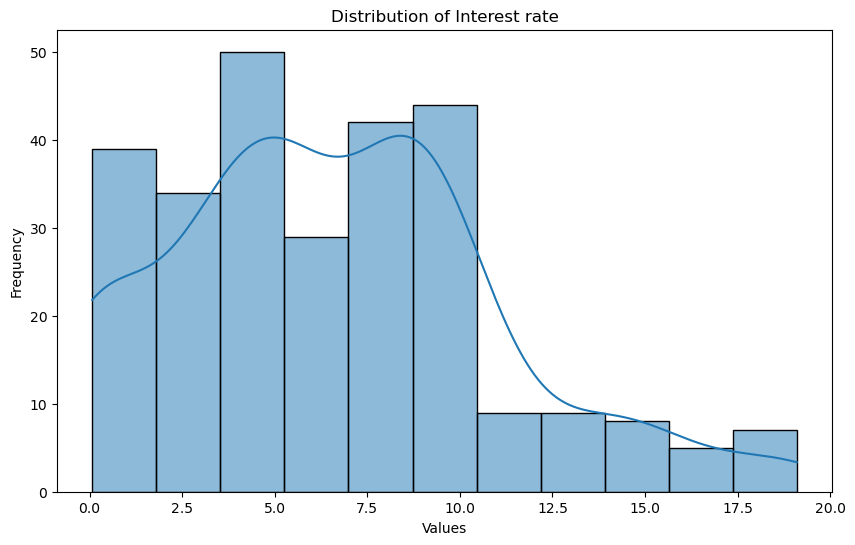

In [438]:
# Draw histogram of the data distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Interest rate'], kde=True) 
plt.title('Distribution of Interest rate') 
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

In [439]:
# Split the training set and the test set, you can change the test_size (0-1), change the scale
X_train, X_test, y_train, y_test = train_test_split(X_res, y, test_size=0.2, random_state=850)

print("Size of training set: {}".format(len(X_train)))
print("Size of test: {}".format(len(X_test)))

Size of training set: 220
Size of test: 56


In [440]:
# Standardize training data and test data
scaler = StandardScaler().fit(X_res)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
print(X_test.shape)

# y-intercept
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Training logistic regression model
model = sm.Logit(y_train, X_train)
result = model.fit()

print(result.summary())


(56, 6)
Optimization terminated successfully.
         Current function value: 0.457172
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  220
Model:                          Logit   Df Residuals:                      213
Method:                           MLE   Df Model:                            6
Date:                Mon, 29 Apr 2024   Pseudo R-squ.:                  0.3372
Time:                        16:03:07   Log-Likelihood:                -100.58
converged:                       True   LL-Null:                       -151.76
Covariance Type:            nonrobust   LLR p-value:                 8.092e-20
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0270      0.191     -0.141      0.888      -0.402       0.348
x1             1.9870

In [441]:

data_pre = {'Interest rate':[5.33],
    'Unemployment rate': [3.8],
    'Inflation rate': [3.477],
    'Real GDP': [22768.886],
    'Change in values of stocks': [3.1],
    'Labor compensation':[5.896],
    }
data_pre = pd.DataFrame(data_pre)


data_pre = scaler.transform(data_pre)


data_pre = sm.add_constant(data_pre, has_constant='add')


prediction = result.predict(data_pre)
print(prediction)

[0.99975411]


In [442]:

y_train_pred = result.predict(X_train)
y_test_pred = result.predict(X_test)

#calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred.round())
test_accuracy = accuracy_score(y_test, y_test_pred.round())

#calculate precesion
train_precision = precision_score(y_train, y_train_pred.round())
test_precision = precision_score(y_test, y_test_pred.round())

# calculate recall
train_recall = recall_score(y_train, y_train_pred.round())
test_recall = recall_score(y_test, y_test_pred.round())

# calculate F1 score
train_f1 = f1_score(y_train, y_train_pred.round())
test_f1 = f1_score(y_test, y_test_pred.round())

# calculate AUC
train_auc = roc_auc_score(y_train, y_train_pred)
test_auc = roc_auc_score(y_test, y_test_pred)

# display the result
print("training set accuracy:", train_accuracy)
print("test set accuracy:", test_accuracy)
print("training set precision:", train_precision)
print("test set precision:", test_precision)
print("training set recall:", train_recall)
print("test set recall:", test_recall)
print("training set F1 score:", train_f1)
print("test set F1 score:", test_f1)
print("training set AUC:", train_auc)
print("test set AUC:", test_auc)

training set accuracy: 0.759090909090909
test set accuracy: 0.75
training set precision: 0.7727272727272727
test set precision: 0.631578947368421
training set recall: 0.6732673267326733
test set recall: 0.631578947368421
training set F1 score: 0.7195767195767195
test set F1 score: 0.631578947368421
training set AUC: 0.8474914718362592
test set AUC: 0.806543385490754


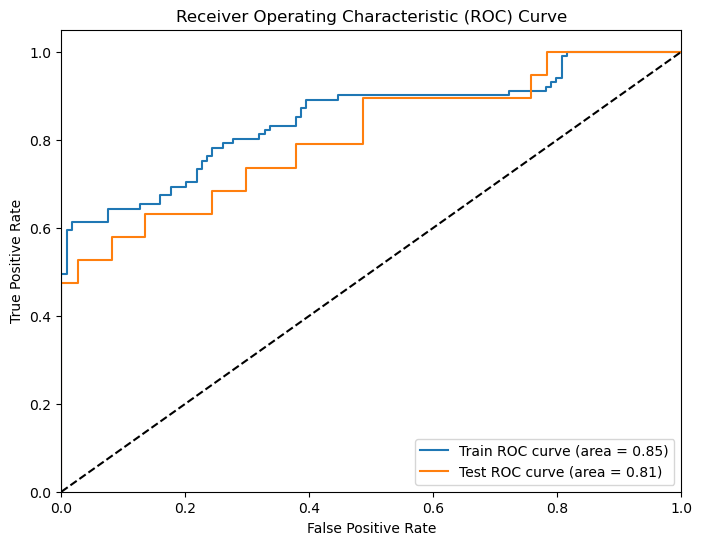

In [443]:

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_pred)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_pred)

# plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label='Train ROC curve (area = %0.2f)' % train_auc)
plt.plot(fpr_test, tpr_test, label='Test ROC curve (area = %0.2f)' % test_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()